In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("Mall_Customers.csv")
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


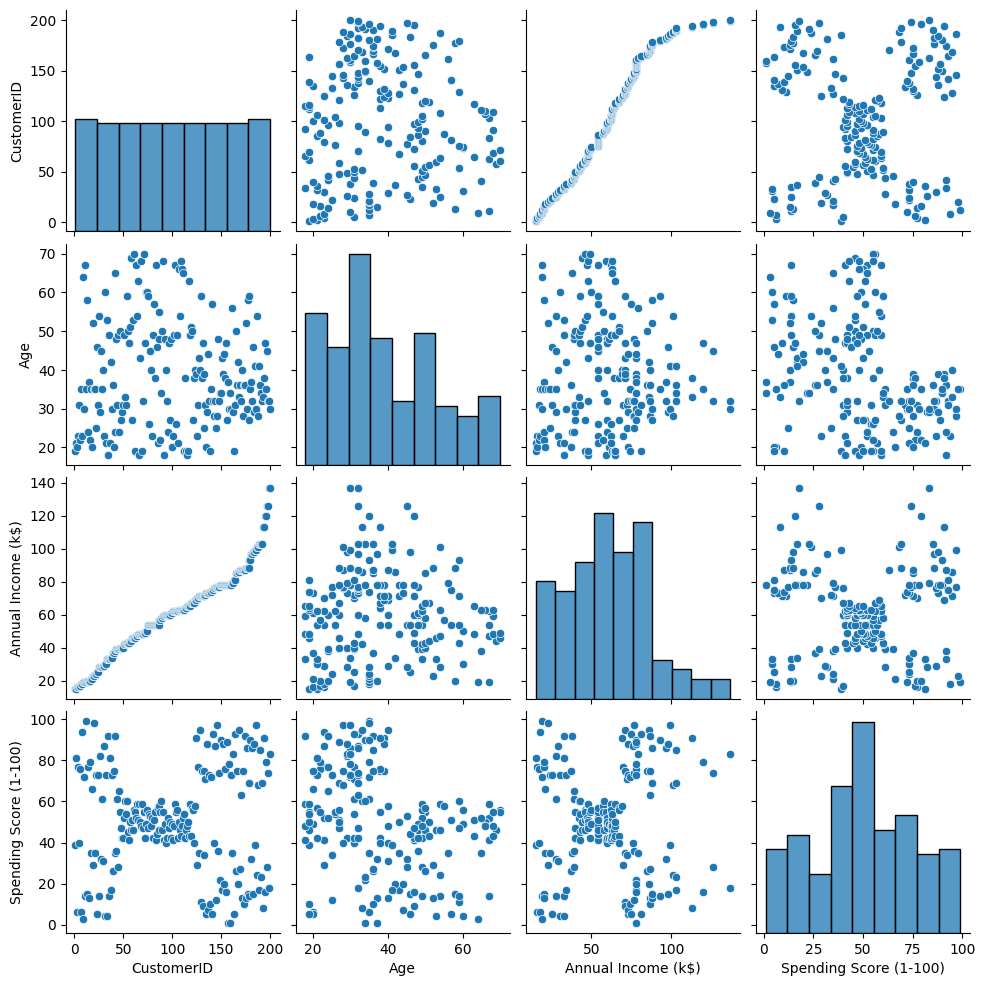

In [3]:
sns.pairplot(df.drop("Gender", axis=1))
plt.show()

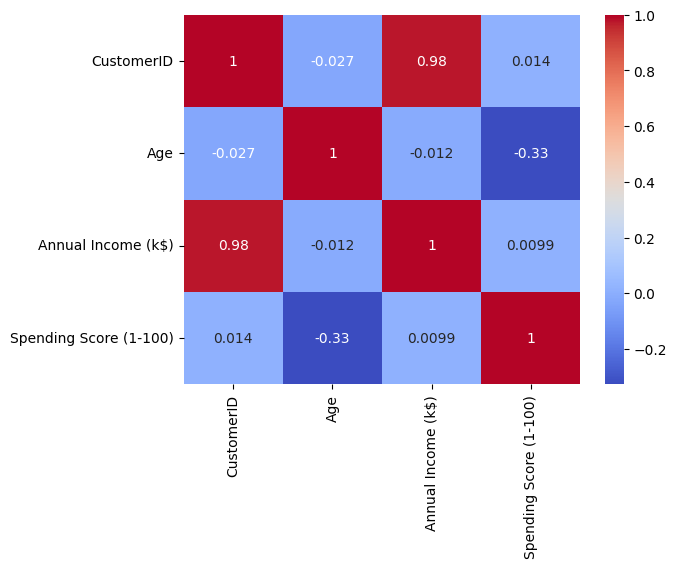

In [4]:
sns.heatmap(df.drop("Gender", axis=1).corr(), annot=True, cmap="coolwarm")
plt.show()

In [5]:
X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


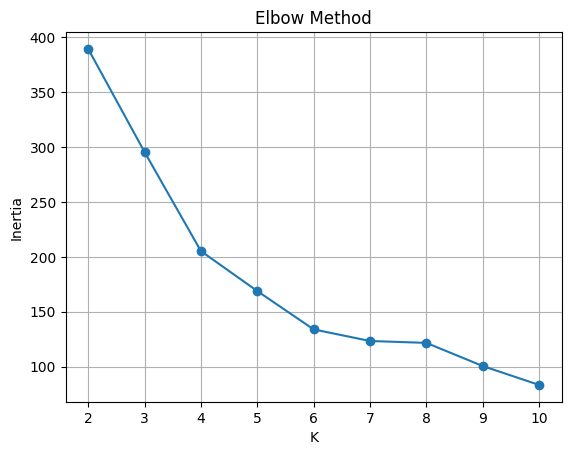

In [7]:
inertia = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [8]:
kmeans = KMeans(n_clusters=5)
k_pred = kmeans.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=5)
gmm_pred = gmm.fit_predict(X_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_pred = dbscan.fit_predict(X_scaled)

agg = AgglomerativeClustering(n_clusters=5)
agg_pred = agg.fit_predict(X_scaled)

In [9]:
models = {
    "KMeans": k_pred,
    "GMM": gmm_pred,
    "DBSCAN": db_pred,
    "Agglomerative": agg_pred
}

for name, y_pred in models.items():
    if len(set(y_pred)) > 1:  
        score = silhouette_score(X_scaled, y_pred)
        print(f"{name} Silhouette Score: {score:.3f}")
    else:
        print(f"{name} Silhouette Score: N/A")

KMeans Silhouette Score: 0.417
GMM Silhouette Score: 0.396
DBSCAN Silhouette Score: 0.185
Agglomerative Silhouette Score: 0.390


In [10]:
def plot_clusters(X_pca, labels, title):
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="viridis", s=50)
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.grid(True)
    plt.show()

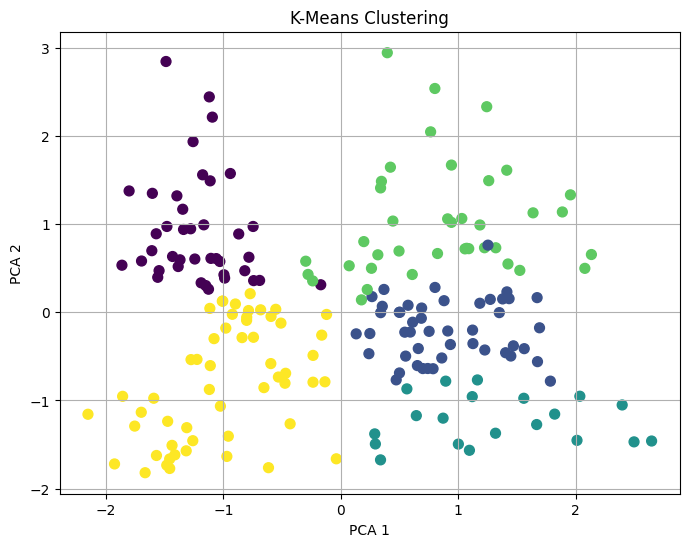

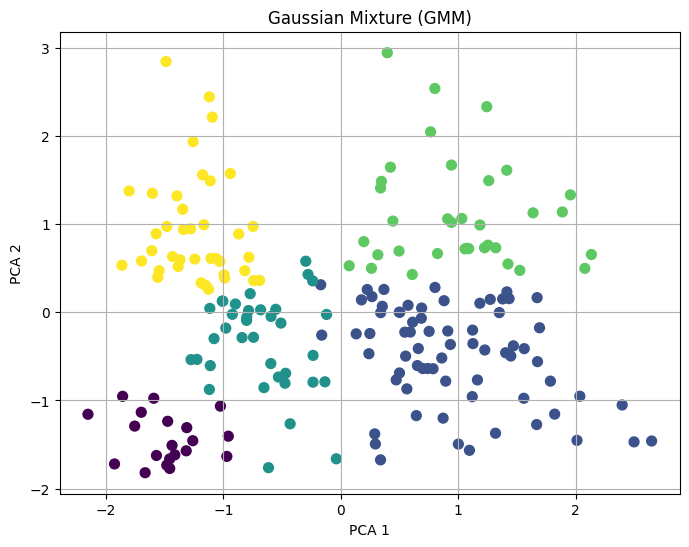

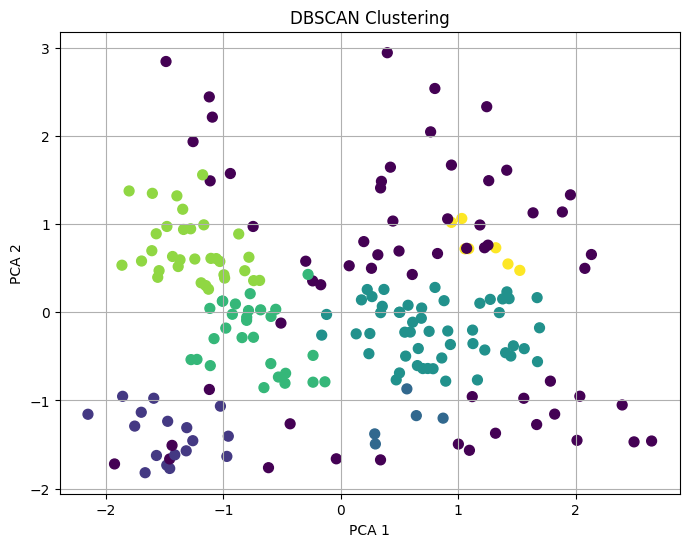

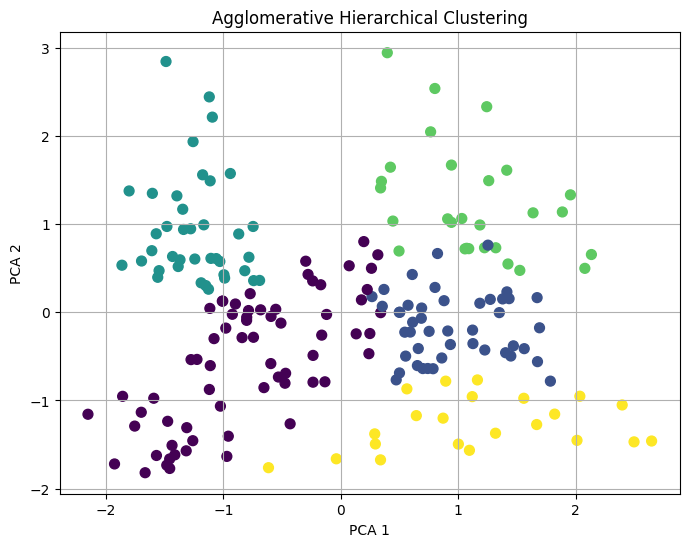

In [11]:
plot_clusters(X_pca, k_pred, "K-Means Clustering")
plot_clusters(X_pca, gmm_pred, "Gaussian Mixture (GMM)")
plot_clusters(X_pca, db_pred, "DBSCAN Clustering")
plot_clusters(X_pca, agg_pred, "Agglomerative Hierarchical Clustering")

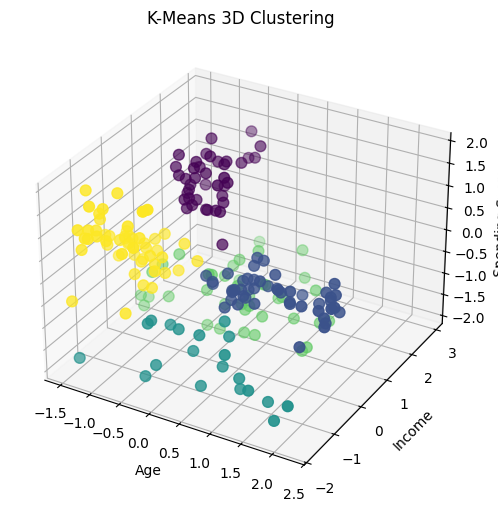

In [12]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_scaled[:,0], X_scaled[:,1], X_scaled[:,2],
    c=k_pred, cmap='viridis', s=60
)

ax.set_title("K-Means 3D Clustering")
ax.set_xlabel("Age")
ax.set_ylabel("Income")
ax.set_zlabel("Spending Score")
plt.show()